In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch

from dvfm.data import sample_moons
from dvfm.ddpm import DDPMSchedule, q_sample

schedule = DDPMSchedule()
data = sample_moons(50_000, seed=0)

print("alpha_bar at t=0:  ", schedule.alpha_bars[0].item())
print("alpha_bar at t=999:", schedule.alpha_bars[-1].item())

alpha_bar at t=0:   0.9998999834060669
alpha_bar at t=999: 4.0358307160204276e-05


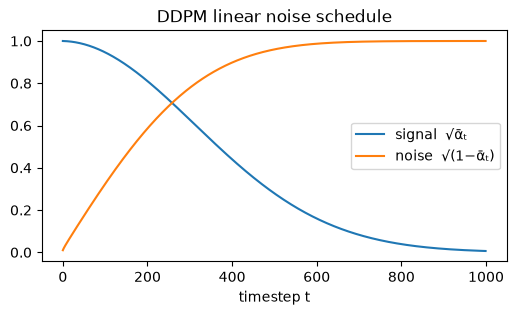

In [2]:
t = torch.arange(schedule.num_timesteps)

plt.figure(figsize=(6, 3))
plt.plot(t, schedule.alpha_bars.sqrt(), label="signal  √ᾱₜ")
plt.plot(t, (1 - schedule.alpha_bars).sqrt(), label="noise  √(1−ᾱₜ)")
plt.xlabel("timestep t")
plt.legend()
plt.title("DDPM linear noise schedule")
plt.show()

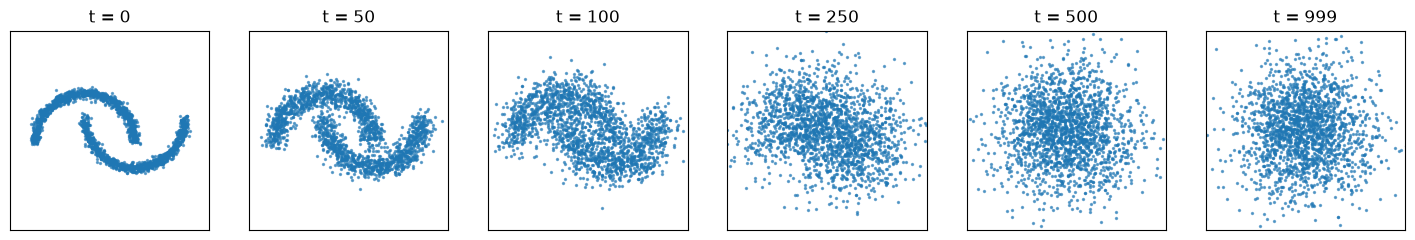

In [3]:
from pathlib import Path

timesteps = [0, 50, 100, 250, 500, 999]
x0 = data[torch.randperm(len(data))[:2000]]
torch.manual_seed(0)
noise = torch.randn_like(x0)  # same noise for every panel, so only t changes

fig, axes = plt.subplots(1, len(timesteps), figsize=(18, 3))
for ax, step in zip(axes, timesteps):
    t_batch = torch.full((len(x0),), step, dtype=torch.long)
    xt = q_sample(schedule, x0, t_batch, noise)
    ax.scatter(xt[:, 0], xt[:, 1], s=2, alpha=0.6)
    ax.set_title(f"t = {step}")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

Path("../assets").mkdir(exist_ok=True)
plt.savefig("../assets/ddpm_forward_process.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
from dvfm.ddpm import ddpm_loss
from dvfm.models import TimeEmbeddingMLP
from dvfm.train import train_model

torch.manual_seed(0)
ddpm_model = TimeEmbeddingMLP()

losses = train_model(
    ddpm_model,
    data,
    loss_fn=lambda model, x0: ddpm_loss(model, schedule, x0),
    num_steps=10_000,
    cosine_schedule=True,
)

step     0 | loss 1.0148
step  1000 | loss 0.2644
step  2000 | loss 0.2452
step  3000 | loss 0.2151
step  4000 | loss 0.2117
step  5000 | loss 0.2056
step  6000 | loss 0.2399
step  7000 | loss 0.2101
step  8000 | loss 0.2282
step  9000 | loss 0.2235


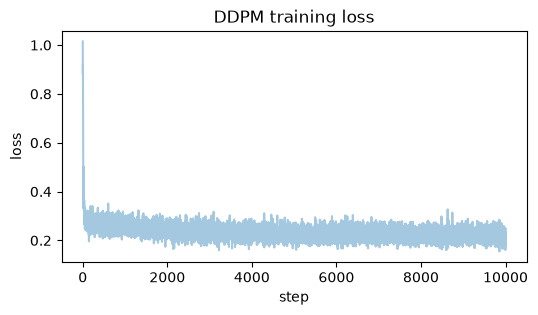

In [5]:
plt.figure(figsize=(6, 3))
plt.plot(losses, alpha=0.4)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("DDPM training loss")
plt.show()